# Bank churn

In [ ]:
import pandas as pd

df1 = pd.read_csv("../data/raw/Bank_Churn.csv")
df2 = pd.read_excel("../data/raw/Bank_Churn_Messy.xlsx")

print(df1.head())
print(df2.head())


   CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0    15634602  Hargrave          619    France  Female   42       2   
1    15647311      Hill          608     Spain  Female   41       1   
2    15619304      Onio          502    France  Female   42       8   
3    15701354      Boni          699    France  Female   39       1   
4    15737888  Mitchell          850     Spain  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  
0       1  
1       0  
2       1  
3       0  
4       0  
   CustomerId   Surname  CreditScore Geography  Ge

In [7]:

# ── 1. BASIC SHAPE & SCHEMA ──────────────────────────────────────────────────
print("=" * 55)
print("df1 (Clean CSV)")
print("=" * 55)
print(f"Shape : {df1.shape[0]:,} rows  x  {df1.shape[1]} columns")
print("\nColumn dtypes:")
print(df1.dtypes)

print("\n" + "=" * 55)
print("df2 (Messy Excel)")
print("=" * 55)
print(f"Shape : {df2.shape[0]:,} rows  x  {df2.shape[1]} columns")
print("\nColumn dtypes:")
print(df2.dtypes)


df1 (Clean CSV)
Shape : 10,000 rows  x  17 columns

Column dtypes:
CustomerId               int64
Surname                 object
CreditScore              int64
Geography               object
Gender                  object
Age                      int64
Tenure                   int64
Balance                float64
NumOfProducts            int64
HasCrCard                int64
IsActiveMember           int64
EstimatedSalary        float64
Exited                   int64
BalanceSalaryRatio     float64
IsZeroBalance            int64
AgeGroup              category
TenureByAge            float64
dtype: object

df2 (Messy Excel)
Shape : 10,001 rows  x  8 columns

Column dtypes:
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure               int64
EstimatedSalary     object
dtype: object


In [9]:

# ── 2. STATISTICAL SUMMARY ───────────────────────────────────────────────────
print("df1 – Descriptive Statistics")
print(df1.describe(include='all').T.to_string())

print("\n\ndf2 – Descriptive Statistics")
print(df2.describe(include='all').T.to_string())


df1 – Descriptive Statistics
                      count unique     top  freq           mean           std         min          25%         50%          75%          max
CustomerId          10000.0    NaN     NaN   NaN  15690940.5694  71936.186123  15565701.0  15628528.25  15690738.0  15753233.75   15815690.0
Surname               10000   2932   Smith    32            NaN           NaN         NaN          NaN         NaN          NaN          NaN
CreditScore         10000.0    NaN     NaN   NaN       650.5288     96.653299       350.0        584.0       652.0        718.0        850.0
Geography             10000      3  France  5014            NaN           NaN         NaN          NaN         NaN          NaN          NaN
Gender                10000      2    Male  5457            NaN           NaN         NaN          NaN         NaN          NaN          NaN
Age                 10000.0    NaN     NaN   NaN        38.9218     10.487806        18.0         32.0        37.0         44

In [11]:

# ── 3. MISSING VALUES ────────────────────────────────────────────────────────
print("df1 – Missing values per column:")
missing_df1 = df1.isnull().sum()
pct_df1     = (df1.isnull().mean() * 100).round(2)
print(pd.DataFrame({'missing': missing_df1, 'pct_%': pct_df1})
        .query('missing > 0')
        .to_string() or "  → No missing values")

print("\ndf2 – Missing values per column:")
missing_df2 = df2.isnull().sum()
pct_df2     = (df2.isnull().mean() * 100).round(2)
result = pd.DataFrame({'missing': missing_df2, 'pct_%': pct_df2}).query('missing > 0')
print(result.to_string() if not result.empty else "  → No missing values")


df1 – Missing values per column:
          missing  pct_%
AgeGroup       22   0.22

df2 – Missing values per column:
         missing  pct_%
Surname        3   0.03
Age            3   0.03


In [12]:

# ── 4. DUPLICATE ROWS ────────────────────────────────────────────────────────
print(f"df1 – Duplicate rows : {df1.duplicated().sum()}")
print(f"df2 – Duplicate rows : {df2.duplicated().sum()}")


df1 – Duplicate rows : 0
df2 – Duplicate rows : 1


In [14]:

# ── 5. DATA QUALITY ISSUES IN df2 ───────────────────────────────────────────
print("Unique Geography values in df1 :", sorted(df1['Geography'].unique()))
print("Unique Geography values in df2 :", sorted(df2['Geography'].unique()))

print("\nUnique Gender values in df1    :", sorted(df1['Gender'].unique()))
print("Unique Gender values in df2    :", sorted(df2['Gender'].unique()))

print("\nAge dtype  – df1:", df1['Age'].dtype,
      " | df2:", df2['Age'].dtype)

print("\nSample EstimatedSalary in df2  :", df2['EstimatedSalary'].head(3).tolist())
print("(Note: currency symbol '€' present – column is stored as object/string)")

# Columns present in df1 but absent in df2
missing_cols = set(df1.columns) - set(df2.columns)
print("\nColumns in df1 NOT in df2 :", missing_cols)


Unique Geography values in df1 : ['France', 'Germany', 'Spain']
Unique Geography values in df2 : ['FRA', 'France', 'French', 'Germany', 'Spain']

Unique Gender values in df1    : ['Female', 'Male']
Unique Gender values in df2    : ['Female', 'Male']

Age dtype  – df1: int64  | df2: float64

Sample EstimatedSalary in df2  : ['€101348.88', '€112542.58', '€113931.57']
(Note: currency symbol '€' present – column is stored as object/string)

Columns in df1 NOT in df2 : {'Balance', 'IsActiveMember', 'TenureByAge', 'IsZeroBalance', 'NumOfProducts', 'HasCrCard', 'BalanceSalaryRatio', 'AgeGroup', 'Exited'}


In [16]:

# ── 6. CLEAN df2 ─────────────────────────────────────────────────────────────
import numpy as np

df2_clean = df2.copy()

# ── 6a. Standardise Geography ────────────────────────────────────────────────
geo_map = {
    'FRA'    : 'France',
    'French' : 'France',
    'FRANCE' : 'France',
    'GER'    : 'Germany',
    'GERMANY': 'Germany',
    'SPA'    : 'Spain',
    'SPAIN'  : 'Spain',
}
df2_clean['Geography'] = (df2_clean['Geography']
                          .str.strip()
                          .replace(geo_map))
print("Geography after cleaning:", sorted(df2_clean['Geography'].unique()))

# ── 6b. Standardise Gender ───────────────────────────────────────────────────
gender_map = {
    'M'   : 'Male',
    'MALE': 'Male',
    'F'    : 'Female',
    'FEMALE': 'Female',
}
df2_clean['Gender'] = (df2_clean['Gender']
                       .str.strip()
                       .replace(gender_map))
print("Gender after cleaning   :", sorted(df2_clean['Gender'].unique()))

# ── 6c. Fix EstimatedSalary (remove '€', convert to float) ──────────────────
df2_clean['EstimatedSalary'] = (df2_clean['EstimatedSalary']
                                .astype(str)
                                .str.replace('€', '', regex=False)
                                .str.replace(',', '', regex=False)
                                .str.strip()
                                .replace('nan', np.nan)
                                .astype(float))
print(f"\nEstimatedSalary dtype   : {df2_clean['EstimatedSalary'].dtype}")

# ── 6d. Fix Age dtype (float → Int64 to support NaN) ────────────────────────
df2_clean['Age'] = df2_clean['Age'].astype('Int64')
print(f"Age dtype               : {df2_clean['Age'].dtype}")

# ── 6e. Drop duplicate rows ──────────────────────────────────────────────────
before = len(df2_clean)
df2_clean = df2_clean.drop_duplicates()
print(f"\nDuplicates removed      : {before - len(df2_clean)}")

# ── 6f. Handle remaining missing values ──────────────────────────────────────
print(f"\nRemaining missing values:\n{df2_clean.isnull().sum()[df2_clean.isnull().sum() > 0]}")

# Fill numeric NaNs with column median, categorical with mode
num_cols = df2_clean.select_dtypes(include=[np.number, 'Int64']).columns
cat_cols = df2_clean.select_dtypes(include='object').columns

for col in num_cols:
    if df2_clean[col].isnull().any():
        median_val = df2_clean[col].median()
        df2_clean[col] = df2_clean[col].fillna(median_val)
        print(f"  Filled '{col}' NaN with median = {median_val}")

for col in cat_cols:
    if df2_clean[col].isnull().any():
        mode_val = df2_clean[col].mode()[0]
        df2_clean[col] = df2_clean[col].fillna(mode_val)
        print(f"  Filled '{col}' NaN with mode  = {mode_val}")

print("\ndf2_clean shape :", df2_clean.shape)


Geography after cleaning: ['France', 'Germany', 'Spain']
Gender after cleaning   : ['Female', 'Male']

EstimatedSalary dtype   : float64
Age dtype               : Int64

Duplicates removed      : 1

Remaining missing values:
Surname    3
Age        3
dtype: int64
  Filled 'Age' NaN with median = 37.0
  Filled 'Surname' NaN with mode  = Smith

df2_clean shape : (10000, 8)


In [ ]:

# ── 7. FINAL VALIDATION ──────────────────────────────────────────────────────
print("df1 (original clean) ─ shape:", df1.shape)
print(df1.dtypes)
print("\ndf2_clean (cleaned)  ─ shape:", df2_clean.shape)
print(df2_clean.dtypes)
print("\ndf2_clean – sample rows:")
df2_clean.head()


df1 (original clean) ─ shape: (10000, 13)
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

df2_clean (cleaned)  ─ shape: (10000, 8)
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  Int64
Tenure               int64
EstimatedSalary    float64
dtype: object

df2_clean – sample rows:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,France,Female,42,2,101348.88
1,15647311,Hill,608,Spain,Female,41,1,112542.58
2,15619304,Onio,502,France,Female,42,8,113931.57
3,15701354,Boni,699,France,Female,39,1,93826.63
4,15737888,Mitchell,850,Spain,Female,43,2,79084.10


# Churn Rate Distribution

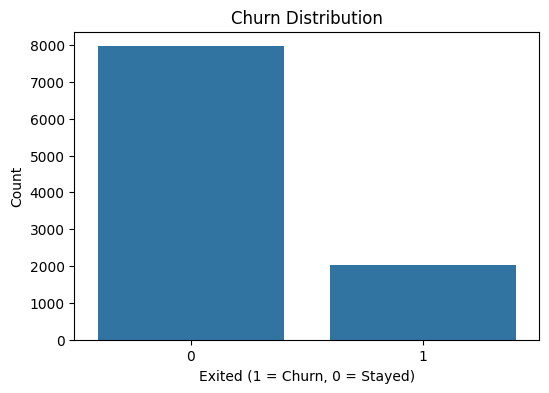

Churn Rate:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Churn Rate Distribution ───────────────────────────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x="Exited", data=df1)
plt.title("Churn Distribution")
plt.xlabel("Exited (1 = Churn, 0 = Stayed)")
plt.ylabel("Count")
plt.show()

print("Churn Rate:")
print(df1["Exited"].value_counts(normalize=True) * 100)


# Univariate Analysis

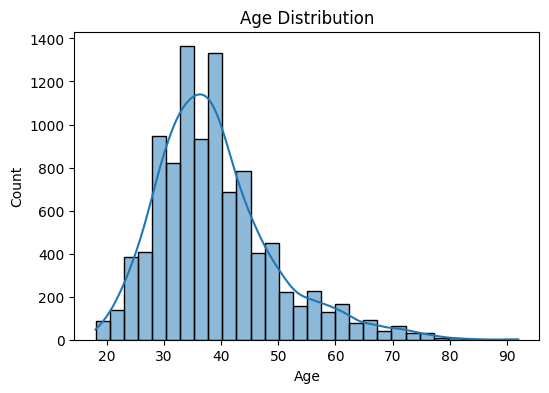

In [19]:
# Age Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df1["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


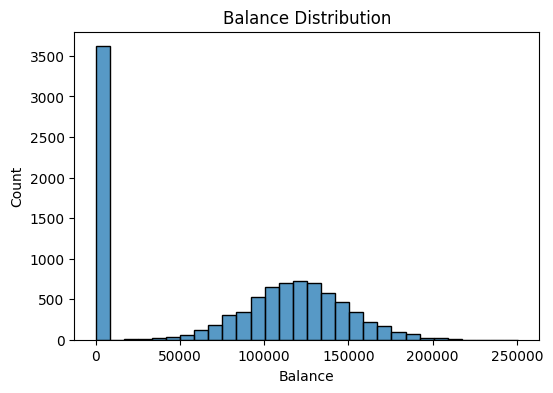

In [20]:
# Balance Distribution
plt.figure(figsize=(6,4))
sns.histplot(df1["Balance"], bins=30)
plt.title("Balance Distribution")
plt.show()

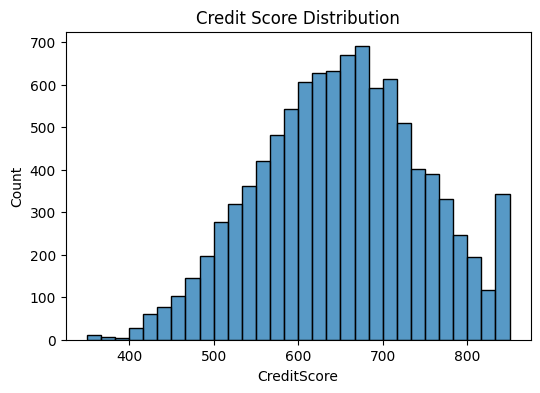

In [21]:
# Credit Score Distribution
plt.figure(figsize=(6,4))
sns.histplot(df1["CreditScore"], bins=30)
plt.title("Credit Score Distribution")
plt.show()

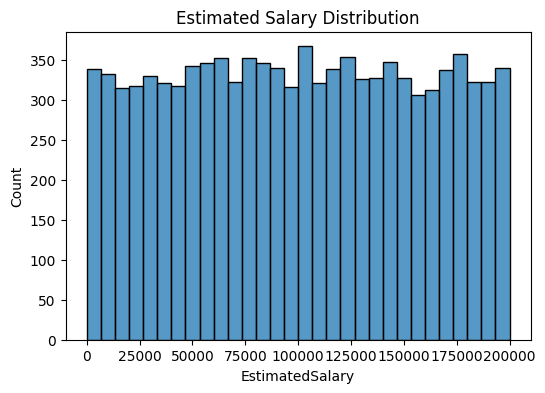

In [22]:
# Salary Distribution
plt.figure(figsize=(6,4))
sns.histplot(df1["EstimatedSalary"], bins=30)
plt.title("Estimated Salary Distribution")
plt.show()

# Bivariate Analysis (Churn vs Features)

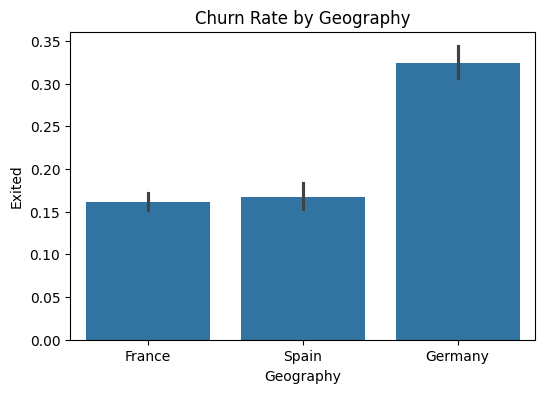

In [23]:
# Churn by Geography
plt.figure(figsize=(6,4))
sns.barplot(x="Geography", y="Exited", data=df1)
plt.title("Churn Rate by Geography")
plt.show()

In [3]:
# Churn by Gender
import seaborn as sns
sns.barplot(x="Gender", y="Exited", data=df1)
plt.title("Churn by Gender")
plt.show()

NameError: name 'df1' is not defined

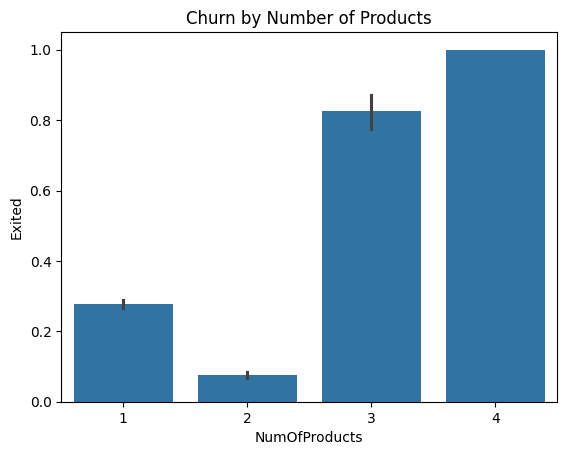

In [ ]:
# Churn by Number of Products
sns.barplot(x="NumOfProducts", y="Exited", data=df1)
plt.title("Churn by Number of Products")
plt.show()

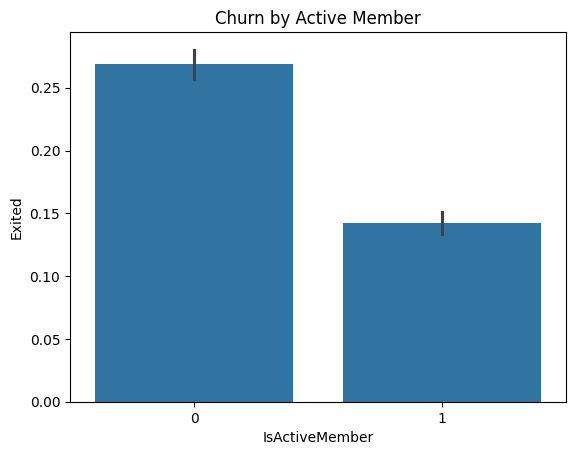

In [ ]:
# Churn by Active Membership
sns.barplot(x="IsActiveMember", y="Exited", data=df1)
plt.title("Churn by Active Member")
plt.show()

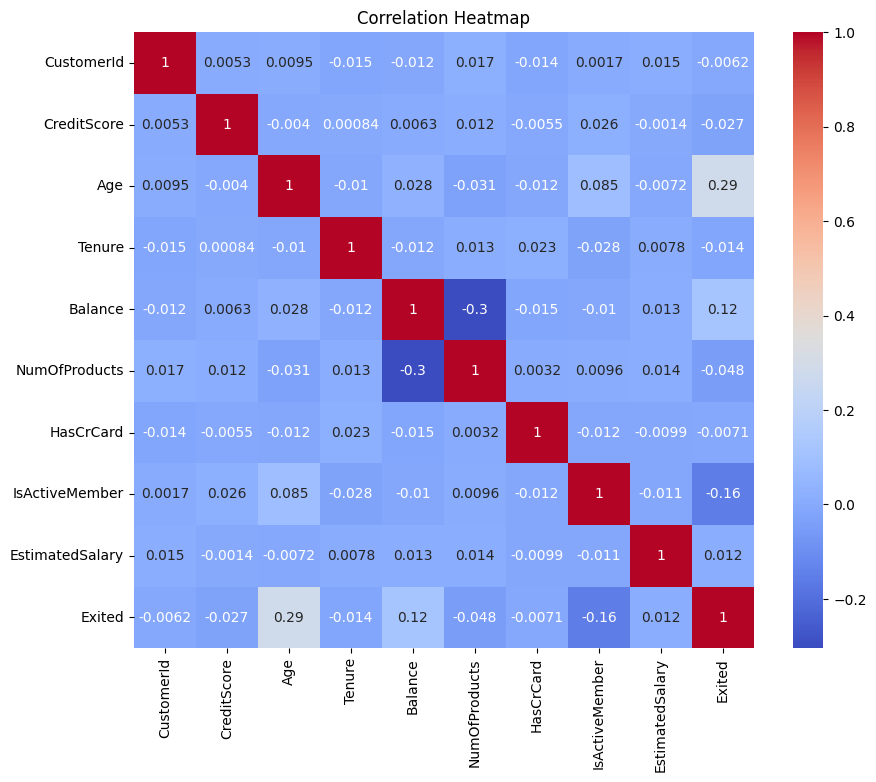

In [ ]:
# Correlation Heatmap
numeric_df = df1.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Feature Engineering


In [4]:
# ── Feature Engineering ──────────────────────────────────────────────────────

# 1. Balance-to-Salary ratio
df1["BalanceSalaryRatio"] = df1["Balance"] / (df1["EstimatedSalary"] + 1)

# 2. Flag customers with zero balance
df1["IsZeroBalance"] = (df1["Balance"] == 0).astype(int)

# 3. Age group bins
df1["AgeGroup"] = pd.cut(df1["Age"],
                         bins=[0, 30, 45, 60, 100],
                         labels=["Young", "Middle", "Senior", "Elder"])

# 4. Tenure relative to age
df1["TenureByAge"] = df1["Tenure"] / df1["Age"]

print("New features added:")
print(df1[["BalanceSalaryRatio", "IsZeroBalance", "AgeGroup", "TenureByAge"]].head())
print(f"\nDataset shape: {df1.shape}")


New features added:
   BalanceSalaryRatio  IsZeroBalance AgeGroup  TenureByAge
0            0.000000              1   Middle     0.047619
1            0.744670              0   Middle     0.024390
2            1.401362              0   Middle     0.190476
3            0.000000              1   Middle     0.025641
4            1.587035              0   Middle     0.046512

Dataset shape: (10000, 17)


In [5]:
# Convert age into categories
df1["AgeGroup"] = pd.cut(
    df1["Age"],
    bins=[18, 30, 50, 100],
    labels=["Young", "Middle", "Senior"]
)
print(df1["AgeGroup"].value_counts())


AgeGroup
Middle    6771
Young     1946
Senior    1261
Name: count, dtype: int64


In [6]:
# Flag customers with zero balance
df1["IsZeroBalance"] = (df1["Balance"] == 0).astype(int)
print(df1["IsZeroBalance"].value_counts())


IsZeroBalance
0    6383
1    3617
Name: count, dtype: int64


In [8]:
# TenureByAge
df1["TenureByAge"] = df1["Tenure"] / df1["Age"]

In [ ]:
df1.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,IsZeroBalance,AgeGroup,TenureByAge
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,1,Middle,0.047619
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0,Middle,0.024390
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0,Middle,0.190476
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1,Middle,0.025641
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0,Middle,0.046512


# Preprocessing

In [10]:
# Encode categorical variables
df = pd.get_dummies(df1, columns=["Geography","Gender","AgeGroup"], drop_first=True)

In [13]:
# Drop non-useful columns
df = df.drop(columns=["CustomerId","Surname"])

In [15]:
# Split features and target
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [17]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ImportError: cannot import name '_promote' from 'scipy.spatial.transform._rotation' (e:\EMiniconda3\envs\y_dtale\Lib\site-packages\scipy\spatial\transform\_rotation.cp313-win_amd64.pyd)

In [ ]:
# Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelling


In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

ImportError: cannot import name '_promote' from 'scipy.spatial.transform._rotation' (e:\EMiniconda3\envs\y_dtale\Lib\site-packages\scipy\spatial\transform\_rotation.cp313-win_amd64.pyd)

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

ImportError: cannot import name '_promote' from 'scipy.spatial.transform._rotation' (e:\EMiniconda3\envs\y_dtale\Lib\site-packages\scipy\spatial\transform\_rotation.cp313-win_amd64.pyd)

In [ ]:
# XGBoost (best for tabular data)
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)


ImportError: sklearn needs to be installed in order to use this module

In [2]:
import numpy as np
import scipy, sklearn
print("numpy :", np.__version__)
print("scipy :", scipy.__version__)
print("sklearn:", sklearn.__version__)


numpy : 2.4.2
scipy : 1.17.0
sklearn: 1.7.1


In [ ]:
# Evaluate Models
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, log_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

print("XGBoost")
print(classification_report(y_test, xgb_pred))